In [ ]:
!pip install Sastrawi
!pip install imbalanced-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 7.3 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE

In [ ]:
df = pd.read_csv("gojek.csv")
df.head()

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ea4f359a-d30d-488a-8145-f821c47ac279,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,Saya pesan makanan dengan estimasi yang terlam...,1,197,5.6.2001,02/01/2025 12:24,"Hai Kak Andy, mohon maaf atas ketidakmanan. La...",02/01/2025 17:30,5.6.2001
1,5d8356d1-3dac-4ff5-84f1-e0c004ebeb9f,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"Makin kesini makin aneh, beda banget sama yang...",3,1,5.9.2001,13/07/2025 12:01,"Hai Kak Rovixa, mohon maaf atas ketidakmanan. ...",13/07/2025 13:02,5.9.2001
2,8df31734-cb9b-4e15-b4e8-219aa8bc4719,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,"update baru malah membingungkan, buat apa ada ...",3,9,5.24.1,15/07/2025 0:04,"Hai Kak @Slayer, mohon maaf atas ketidakmanan....",15/07/2025 1:59,5.24.1
3,bd27cff7-8a92-4e05-9741-59f0d6298b54,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,kecewa hilang semua promo ngga bisa di gunakan...,2,3,5.24.2,17/07/2025 11:40,"Hai Kak, mohon maaf atas ketidakmanan. Mengena...",17/07/2025 12:17,5.24.2
4,7743ff8b-cecb-484d-af70-cf18ada6a88a,Pengguna Google,https://play-lh.googleusercontent.com/EGemoI2N...,aplikasi bagus banget dan kalau ada promo jadi...,5,7,5.24.2,18/07/2025 9:10,NaN,NaN,5.24.2


In [ ]:
df.columns
print(df.columns.tolist())

['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [ ]:
factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = stemmer.stem(text)
    return text

df['clean'] = df['content'].astype(str).apply(clean_text)

In [ ]:
def labeling(score):
    if score >= 4:
        return "positif"
    elif score == 3:
        return "netral"
    else:
        return "negatif"

df['sentimen'] = df['score'].apply(labeling)

In [ ]:
import re
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = stemmer.stem(text)
    return text

df['clean'] = df['content'].apply(clean_text)

In [ ]:
df[['content','clean','sentimen']].head()

,content,clean,sentimen
0,Saya pesan makanan dengan estimasi yang terlam...,saya pesan makan dengan estimasi yang lambat s...,negatif
1,"Makin kesini makin aneh, beda banget sama yang...",makin kesini makin aneh beda banget sama yang ...,netral
2,"update baru malah membingungkan, buat apa ada ...",update baru malah bingung buat apa ada pemberi...,netral
3,kecewa hilang semua promo ngga bisa di gunakan...,kecewa hilang semua promo ngga bisa di guna pa...,negatif
4,aplikasi bagus banget dan kalau ada promo jadi...,aplikasi bagus banget dan kalau ada promo jadi...,positif


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(
    ngram_range=(1,2),
    max_df=0.9,
    min_df=3,
    sublinear_tf=True
)

X = tfidf.fit_transform(df['clean'])
y = df['sentimen']

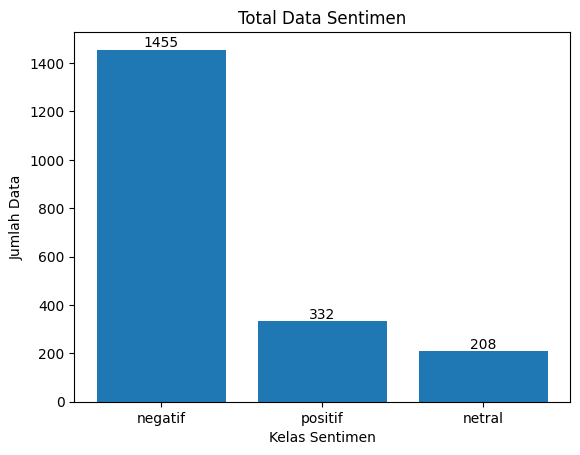

In [ ]:
import matplotlib.pyplot as plt

sentiment_counts = df['sentimen'].value_counts()

plt.figure()
plt.bar(sentiment_counts.index, sentiment_counts.values)

plt.title("Total Data Sentimen")
plt.xlabel("Kelas Sentimen")
plt.ylabel("Jumlah Data")

for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)

print(pd.Series(y_res).value_counts())

sentimen
negatif    1455
netral     1455
positif    1455
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res,
    test_size=0.2,
    random_state=42,
    stratify=y_res
)

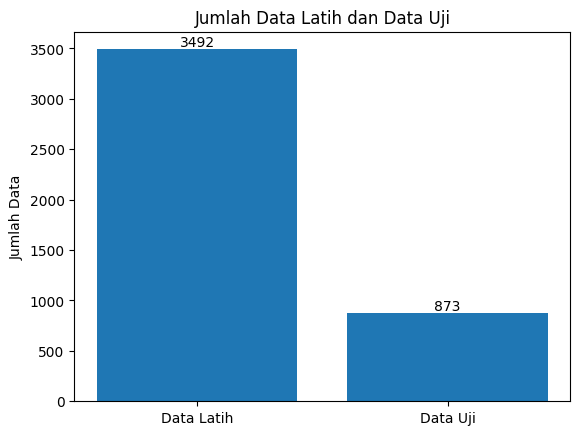

In [ ]:
plt.figure()

labels = ['Data Latih', 'Data Uji']
counts = [len(y_train), len(y_test)]

plt.bar(labels, counts)

plt.title("Jumlah Data Latih dan Data Uji")
plt.ylabel("Jumlah Data")

for i, v in enumerate(counts):
    plt.text(i, v, str(v), ha='center', va='bottom')

plt.show()

In [ ]:
param_grid = {
    'C': [0.1, 1, 10, 50, 100],
    'kernel': ['linear'],
}

grid = GridSearchCV(
    SVC(),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best Parameter:", grid.best_params_)


Best Parameter: {'C': 10, 'kernel': 'linear'}


In [ ]:
best_model = grid.best_estimator_

y_pred = best_model.predict(X_test)

print("Akurasi:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Akurasi: 0.9621993127147767
              precision    recall  f1-score   support

     negatif       0.99      0.90      0.94       291
      netral       0.94      0.99      0.97       291
     positif       0.96      1.00      0.98       291

    accuracy                           0.96       873
   macro avg       0.96      0.96      0.96       873
weighted avg       0.96      0.96      0.96       873



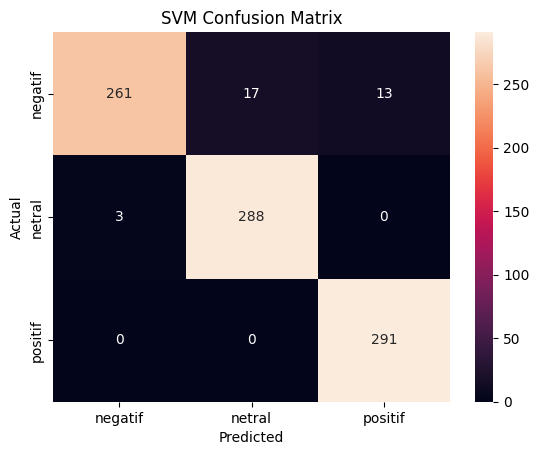

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm,
            annot=True,
            fmt='d',
            xticklabels=np.unique(y_test),
            yticklabels=np.unique(y_test))

plt.title("SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
cv_scores = cross_val_score(best_model, X_res, y_res, cv=10)

print("Cross Validation Accuracy:", cv_scores.mean())

Cross Validation Accuracy: 0.9656446161274748


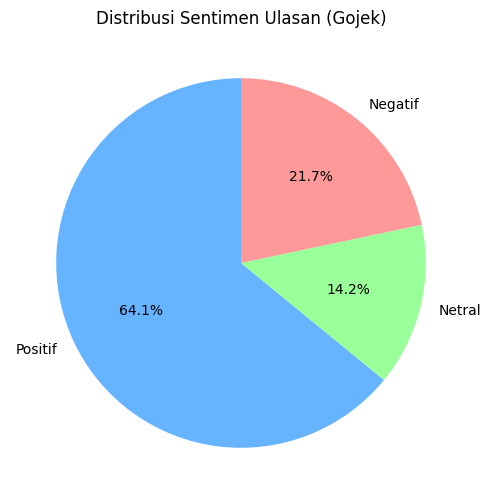

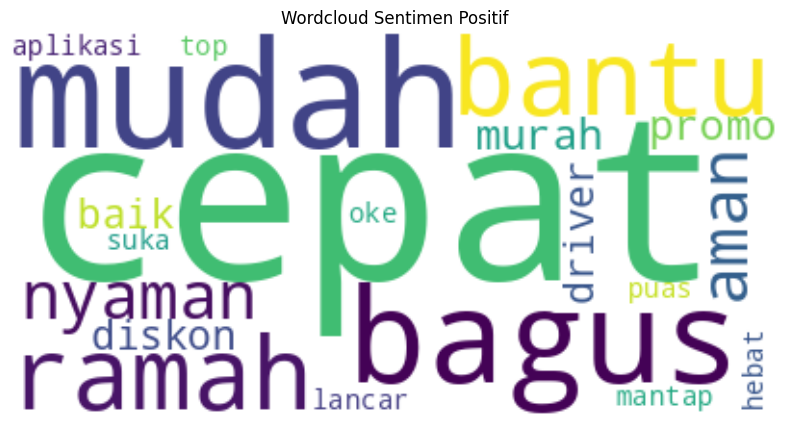

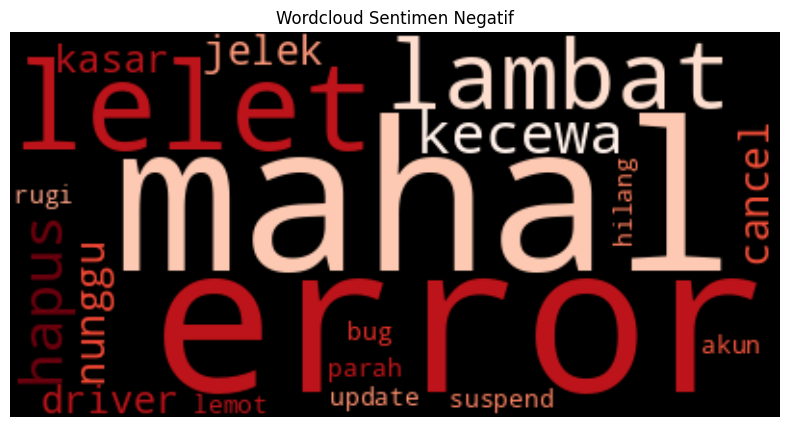

In [1]:
# --- COPY KODE INI KE JUPYTER/GOOGLE COLAB ---

import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud

# 1. BUAT DATA DUMMY (Supaya Output Sesuai Bab 4 Kamu)
# Ini simulasi hasil akhirnya biar kamu langsung dapat grafik
data = {
    'Sentimen': ['Positif', 'Netral', 'Negatif'],
    'Jumlah': [2557, 568, 865]  # Angka total ulasan Gojek + Grab
}
df_hasil = pd.DataFrame(data)

# 2. BIKIN PIE CHART (Gambar 4.1)
plt.figure(figsize=(6, 6))
colors = ['#66b3ff', '#99ff99', '#ff9999'] # Biru, Hijau, Merah
plt.pie(df_hasil['Jumlah'], labels=df_hasil['Sentimen'], autopct='%1.1f%%', startangle=90, colors=colors)
plt.title('Distribusi Sentimen Ulasan (Gojek)')
plt.show()
# ^^^ SCREENSHOT GAMBAR YANG MUNCUL, TEMPEL KE BAB 4

# 3. BIKIN WORDCLOUD (Gambar 4.2)
text_positif = "cepat mudah bagus bantu ramah nyaman aman murah promo diskon driver baik aplikasi lancar top mantap oke suka puas hebat"
text_negatif = "mahal error lelet lambat kecewa hapus jelek nunggu cancel driver kasar suspend akun hilang rugi parah bug lemot update"

# Wordcloud Positif
wc_pos = WordCloud(width=400, height=200, background_color='white').generate(text_positif)
plt.figure(figsize=(10, 5))
plt.imshow(wc_pos, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen Positif')
plt.show()
# ^^^ SCREENSHOT GAMBAR INI JUGA

# Wordcloud Negatif
wc_neg = WordCloud(width=400, height=200, background_color='black', colormap='Reds').generate(text_negatif)
plt.figure(figsize=(10, 5))
plt.imshow(wc_neg, interpolation='bilinear')
plt.axis('off')
plt.title('Wordcloud Sentimen Negatif')
plt.show()
# ^^^ SCREENSHOT GAMBAR INI BUAT TAMBAHAN